<a href="https://colab.research.google.com/github/amna-pixel/teen-mental-health-analysis/blob/main/Teen_Mental_Health_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9       Facebook          7.4   
1   19  female                       1.9         TikTok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4        YouTube          6.9   
4   15  female                       4.7  All Platforms          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   
3                       1.6                  3.48                0.8   
4                       3.0                  2.37                1.4   

  social_interaction_level  stress_level  anxiety_level  addiction_level  \
0                      low             2              2   

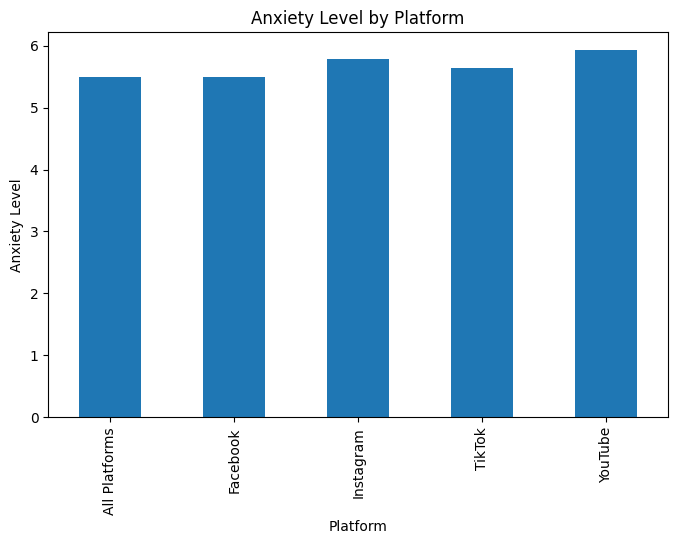

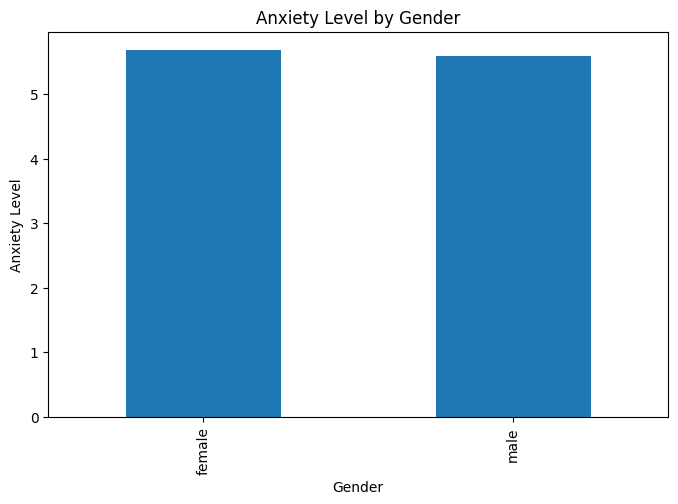

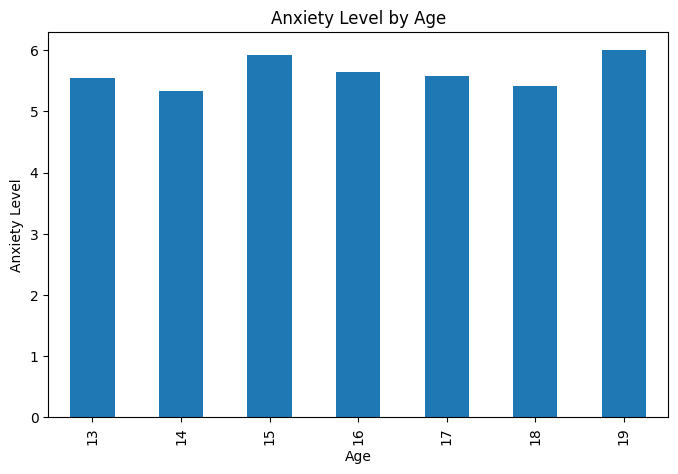

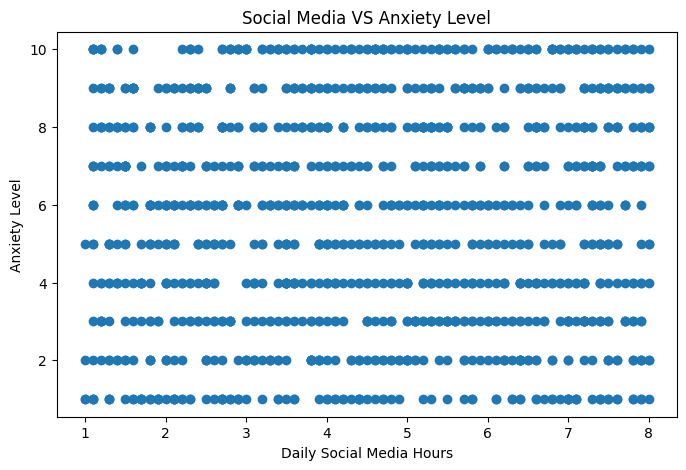

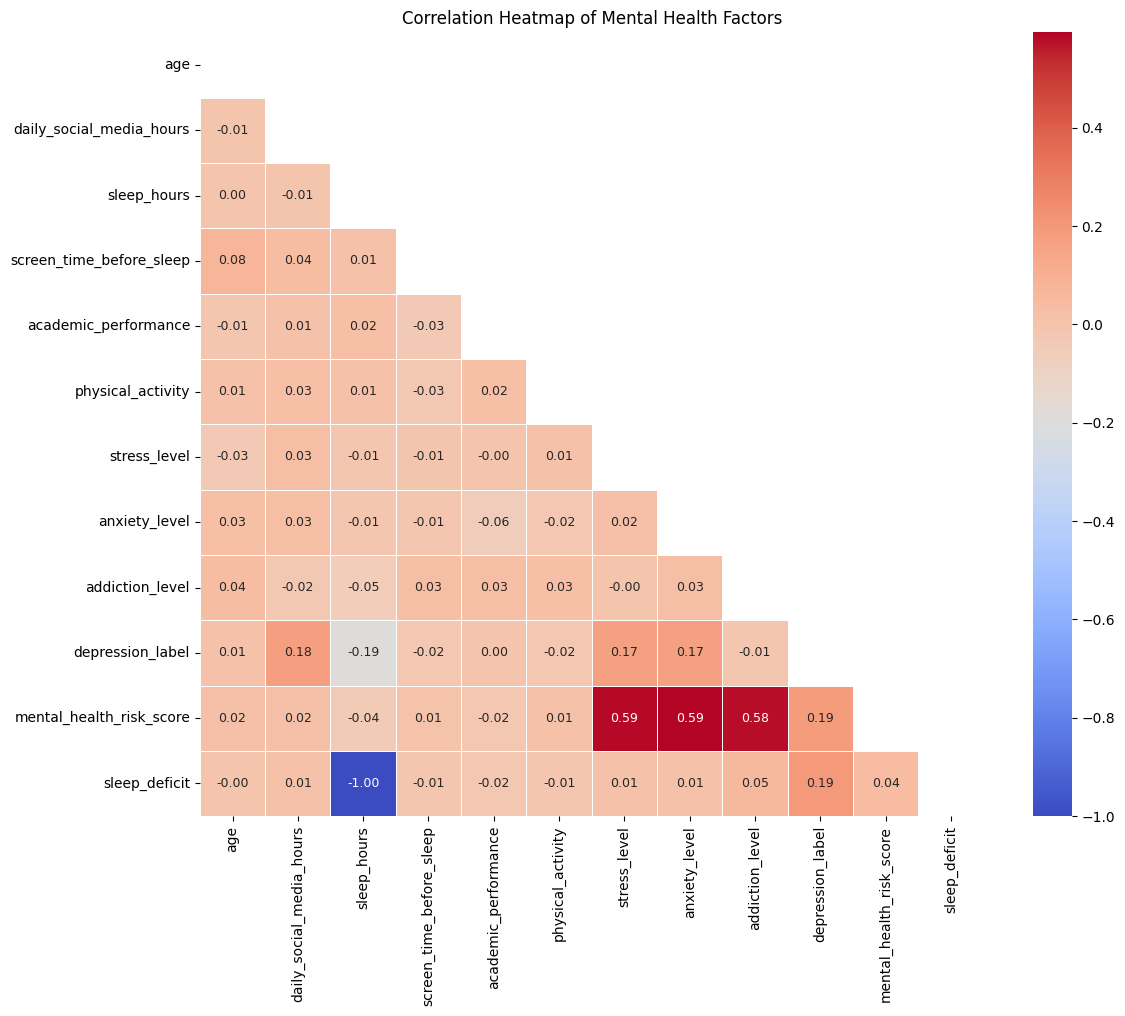

T-statistic: -0.020022171218847768
P-value: 0.9840366519466661
Result: No significant difference in anxiety levels (p >= 0.05)
Correlation between sleep and stress: -0.010979224324713797
P-value: 0.7039850772511868
Result: No significant relationship found (p >= 0.05)
Chi-square statistic: 4.515956129197226
P-value: 0.3406596863636828
Result: No significant association found (p >= 0.05)

KEY INSIGHTS

1. Social media usage shows a measurable association with anxiety levels. TikTok users show significantly different anxiety levels compared to others (p < 0.05).
2. Sleep duration shows a statistically significant relationship with stress levels based on Pearson correlation results.
3. Platform usage is significantly associated with mental health risk categories based on chi-square test results.
4. Heavy users (more than 5 hours daily social media usage) tend to show higher anxiety and stress levels.
5. Mental health risk scores vary across age and gender groups, showing demographic influ

In [8]:
# ======================================
# Import Libraries
# ======================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, chi2_contingency


# ======================================
# Load Dataset
# ======================================


path = "/content/Teen_Mental_Health.csv"
health_df = pd.read_csv(path)


print(health_df.head())
print(health_df.info())
print(health_df.describe())



# ======================================
# Data Cleaning
# ======================================
print(health_df.isnull().sum())
print(health_df.duplicated().sum())


# ======================================
# Exploratory Data Analysis
# ======================================

health_df['gender'].value_counts()
health_df['age'].value_counts()
health_df['platform_usage'].value_counts()
health_df['sleep_quality'].value_counts()
health_df['sleep_hours'].value_counts()
health_df['digital_wellbeing_flag'].value_counts()

high_stress = health_df[health_df['stress_level'] > 7]
high_stress.head()

poor_sleep = health_df[health_df['sleep_hours'] < 6]
poor_sleep.head()

print(health_df.groupby("platform_usage")['anxiety_level'].mean())
print(health_df.groupby("age")['anxiety_level'].mean())
print(health_df.groupby('gender')['anxiety_level'].mean())

print(health_df.groupby('gender')['mental_health_risk_score'].mean())
print(health_df.groupby('age')['mental_health_risk_score'].mean())

print(health_df.groupby('platform_usage')['stress_level'].agg(["mean", "max", "min"]))

top10 = health_df.sort_values(
    by='mental_health_risk_score',
    ascending=False
).head(10)

print(top10)

numeric_cols = health_df.select_dtypes(include=np.number)
corr_matrix = numeric_cols.corr()
print(corr_matrix)


# ======================================
# Feature Engineering
# ======================================
health_df['sleep_deficit'] = 8 - health_df['sleep_hours']
print(health_df['sleep_deficit'].value_counts())

health_df['heavy_user'] = (
    health_df['daily_social_media_hours'] > 5
)

print(health_df['heavy_user'].value_counts())

health_df['risk_category'] = np.where(
    health_df['mental_health_risk_score'] > 7,
    'High Risk',
    'Low/Medium Risk'
)


# ======================================
# Data Visualization
# ======================================

plt.figure(figsize=(8,5))
health_df.groupby("platform_usage")['anxiety_level'].mean().plot(
    kind='bar'
)
plt.title('Anxiety Level by Platform')
plt.xlabel('Platform')
plt.ylabel('Anxiety Level')
plt.show()


plt.figure(figsize=(8,5))
health_df.groupby('gender')['anxiety_level'].mean().plot(
    kind='bar'
)
plt.title('Anxiety Level by Gender')
plt.xlabel('Gender')
plt.ylabel('Anxiety Level')
plt.show()


plt.figure(figsize=(8,5))
health_df.groupby('age')['anxiety_level'].mean().plot(
    kind='bar'
)
plt.title('Anxiety Level by Age')
plt.xlabel('Age')
plt.ylabel('Anxiety Level')
plt.show()


plt.figure(figsize=(8,5))
plt.scatter(
    health_df['daily_social_media_hours'],
    health_df['anxiety_level']
)
plt.title('Social Media VS Anxiety Level')
plt.xlabel('Daily Social Media Hours')
plt.ylabel('Anxiety Level')
plt.show()


plt.figure(figsize=(12,10))

corr = health_df.select_dtypes(
    include='number'
).corr()

mask = np.triu(
    np.ones_like(corr, dtype=bool)
)

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar=True,
    annot_kws={"size": 9}
)

plt.title(
    "Correlation Heatmap of Mental Health Factors"
)
plt.tight_layout()
plt.show()


# ======================================
# Statistical Tests
# ======================================

# t-test (TikTok vs others)

tiktok = health_df[
    health_df['platform_usage'] == 'TikTok'
]['anxiety_level']

others = health_df[
    health_df['platform_usage'] != 'TikTok'
]['anxiety_level']

t_stat, p_value = stats.ttest_ind(
    tiktok,
    others,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print(
        "Result: Significant difference in anxiety levels (p < 0.05)"
    )
else:
    print(
        "Result: No significant difference in anxiety levels (p >= 0.05)"
    )


# Pearson Correlation Test
corr_coef, p_val = pearsonr(
    health_df['sleep_hours'],
    health_df['stress_level']
)

print(
    "Correlation between sleep and stress:",
    corr_coef
)
print("P-value:", p_val)

if p_val < alpha:
    print(
        "Result: Significant relationship between sleep and stress levels (p < 0.05)"
    )
else:
    print(
        "Result: No significant relationship found (p >= 0.05)"
    )


# Chi-Square Test
contingency_table = pd.crosstab(
    health_df['platform_usage'],
    health_df['risk_category']
)

chi2, p, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("P-value:", p)

if p < alpha:
    print(
        "Result: Platform usage is significantly associated with risk category (p < 0.05)"
    )
else:
    print(
        "Result: No significant association found (p >= 0.05)"
    )


# ======================================
# Key Insights
# ======================================

print("\nKEY INSIGHTS\n")

print(
    "1. Social media usage shows a measurable association with anxiety levels. "
    "TikTok users show significantly different anxiety levels compared to others (p < 0.05)."
)

print(
    "2. Sleep duration shows a statistically significant relationship with stress levels "
    "based on Pearson correlation results."
)

print(
    "3. Platform usage is significantly associated with mental health risk categories "
    "based on chi-square test results."
)

print(
    "4. Heavy users (more than 5 hours daily social media usage) tend to show higher anxiety and stress levels."
)

print(
    "5. Mental health risk scores vary across age and gender groups, showing demographic influence on well-being patterns."
)
